# 02 — Forecasting de Consumo (global · tipo de café · país)

Proyección de consumo a 5 años (2020/21–2024/25) con **rigor**:

- Selección de modelo por **backtest de origen móvil** (rolling-origin), no un único holdout — elimina el sesgo de selección.
- Modelos ajustados en **escala log** (crecimiento compuesto; intervalos que nunca caen bajo 0).
- **Intervalos empíricos** (P10–P90) desde los residuos del backtest, para todos los modelos.
- Deep learning descartado por diseño (~30 obs/serie).

El dataset no tiene precios: se proyecta **consumo**, no precio (ver `01_eda`).

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_prep import build_long_dataset
from forecasting import forecast_global, forecast_by_type, forecast_series, rolling_backtest
import viz; viz.set_style()
long_df = build_long_dataset()
valid = long_df[long_df['is_valid_series']]

## 1. Backtest comparativo de modelos (rolling-origin) — ejemplo Brasil

In [2]:
brazil = valid[valid.Country=='Brazil'].sort_values('fiscal_year_start')['consumption'].to_numpy(float)
rolling_backtest(brazil, horizon=1).round(2)

,model,mape,mae
0,arima,1.48,19253220.88
1,holt_winters,1.89,24466283.87
2,naive,1.91,24804000.00
3,linear,3.31,42651592.04


## 2. Forecast global con banda de confianza empírica

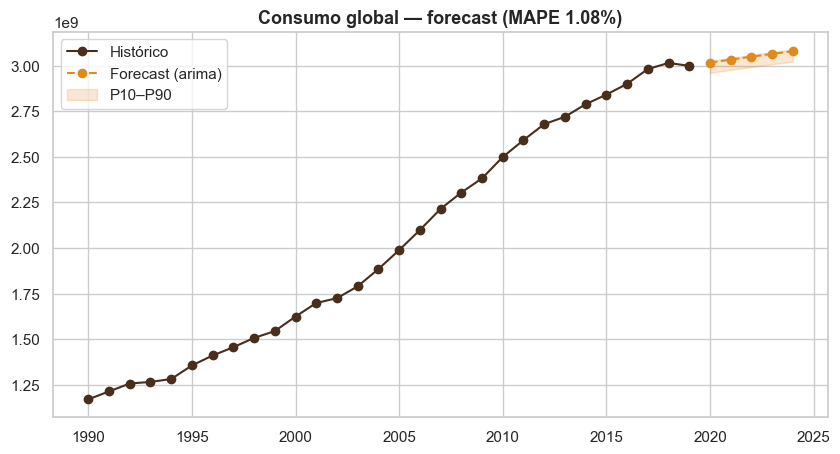

In [3]:
g = forecast_global(long_df)
fy = np.arange(g['years'][-1]+1, g['years'][-1]+1+len(g['point']))
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(g['years'], g['history'], marker='o', color='#4A2E1C', label='Histórico')
ax.plot(fy, g['point'], marker='o', ls='--', color='#E08A1E', label=f"Forecast ({g['model']})")
if g['lower'] is not None:
    ax.fill_between(fy, g['lower'], g['upper'], color='#E08A1E', alpha=0.2, label='P10–P90')
ax.set_title(f"Consumo global — forecast (MAPE {g['mape']:.2f}%)"); ax.legend(); plt.show()

## 3. Forecast por tipo de café (4 series agregadas)

In [4]:
rows=[]
for t, r in forecast_by_type(long_df).items():
    rows.append({'tipo': t, 'modelo': r['model'], 'MAPE_%': round(r['mape'],2),
                 '2019/20': r['history'][-1], '2024/25': round(r['point'][-1])})
pd.DataFrame(rows)

,tipo,modelo,MAPE_%,2019/20,2024/25
0,Arabica,naive,0.78,5.636858e+08,563685840
1,Arabica/Robusta,arima,1.61,1.526580e+09,1586266704
2,Robusta,arima,1.06,5.962560e+07,59625600
3,Robusta/Arabica,naive,2.23,8.490000e+08,849000000


## 4. Forecast de países individuales (top mercados)

In [5]:
for c in ['Brazil','Indonesia','Ethiopia','Viet Nam']:
    s = valid[valid.Country==c].sort_values('fiscal_year_start')['consumption'].to_numpy(float)
    r = forecast_series(s, 5)
    print(f"{c:12s} modelo={r['model']:12s} MAPE={r['mape']:.2f}%  2024/25={r['point'][-1]:,.0f}")

Brazil       modelo=arima        MAPE=1.48%  2024/25=1,282,574,988


Indonesia    modelo=naive        MAPE=1.67%  2024/25=288,360,000


Ethiopia     modelo=holt_winters MAPE=0.48%  2024/25=253,061,674


Viet Nam     modelo=arima        MAPE=1.32%  2024/25=168,779,788


## 5. Conclusión

El MAPE de backtest es bajo para los grandes mercados (típicamente <5%), muy por debajo del baseline naive. La comparación justa contra un **modelo ML global pooled (HistGradientBoosting)** está en `scripts/run_pipeline.py` y se resume en el informe web (`reports/web/forecasting.html`): para estas series maduras y suaves, los modelos clásicos ganan, y se eligen *por evidencia*.